# Uber Trips Visualization Project

The main goal of this project is to perform an Exploratory Data Analysis (EDA) on Uber ride datasets using Python. By analyzing trip timestamps and location coordinates, the project reveals core urban mobility patterns, temporal demand fluctuations, and user movement behavior to derive data-driven insights.

<img src='https://media.assettype.com/freepressjournal/2024-09-11/1y6oca51/FotoJet%20(92).jpg' width='750'>

In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

# EDA 

In [2]:
df=pd.read_csv('uber-raw-data-sep14.csv')

In [3]:
df.head()

,Date/Time,Lat,Lon,Base
0,9/1/2014 0:01:00,40.2201,-74.0021,B02512
1,9/1/2014 0:01:00,40.7500,-74.0027,B02512
2,9/1/2014 0:03:00,40.7559,-73.9864,B02512
3,9/1/2014 0:06:00,40.7450,-73.9889,B02512
4,9/1/2014 0:11:00,40.8145,-73.9444,B02512


In [4]:
df.tail()

,Date/Time,Lat,Lon,Base
1028131,9/30/2014 22:57:00,40.7668,-73.9845,B02764
1028132,9/30/2014 22:57:00,40.6911,-74.1773,B02764
1028133,9/30/2014 22:58:00,40.8519,-73.9319,B02764
1028134,9/30/2014 22:58:00,40.7081,-74.0066,B02764
1028135,9/30/2014 22:58:00,40.7140,-73.9496,B02764


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1028136 entries, 0 to 1028135
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Date/Time  1028136 non-null  object 
 1   Lat        1028136 non-null  float64
 2   Lon        1028136 non-null  float64
 3   Base       1028136 non-null  object 
dtypes: float64(2), object(2)
memory usage: 31.4+ MB


In [6]:
df.shape

(1028136, 4)

In [7]:
df.isnull().sum()

Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64

In [8]:
df.describe()

,Lat,Lon
count,1.028136e+06,1.028136e+06
mean,4.073922e+01,-7.397182e+01
std,4.082861e-02,5.831413e-02
min,3.998970e+01,-7.477360e+01
25%,4.072040e+01,-7.399620e+01
50%,4.074180e+01,-7.398310e+01
75%,4.076120e+01,-7.396280e+01
max,4.134760e+01,-7.271630e+01


In [9]:
df.corr(numeric_only=True)

,Lat,Lon
Lat,1.000000,0.046376
Lon,0.046376,1.000000


In [12]:
# 1. Convert Date/Time to datetime objects
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# 2. Extract useful features
df['Hour'] = df['Date/Time'].dt.hour
df['Day'] = df['Date/Time'].dt.day
df['Weekday'] = df['Date/Time'].dt.day_name()

In [13]:
df.sample()

,Date/Time,Lat,Lon,Base,Hour,Day,Weekday
504770,2014-09-18 17:49:00,40.7411,-73.9844,B02617,17,18,Thursday


<Axes: xlabel='Hour'>

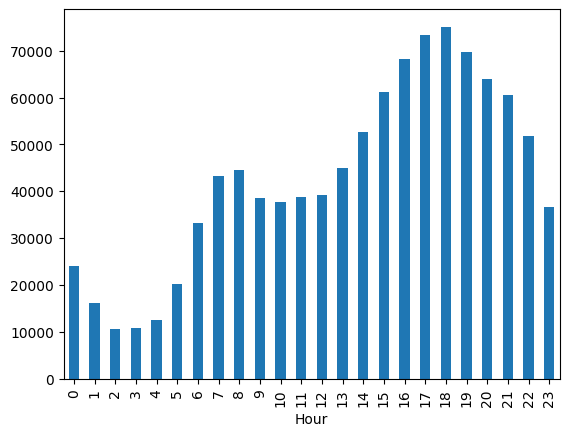

In [14]:
df["Hour"].value_counts().sort_index().plot.bar()

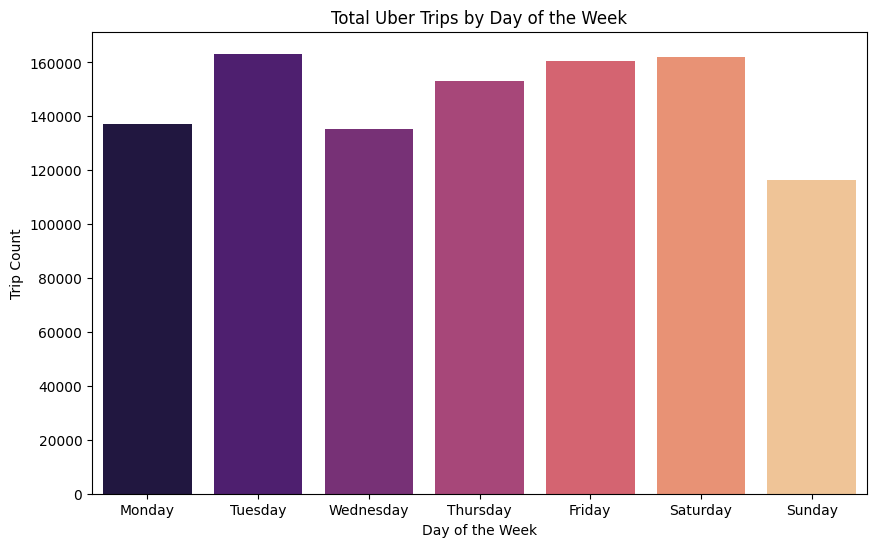

In [18]:
# Trips by Weekday (Bar Chart)
# Sort days to ensure they appear in order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))
sns.countplot(x='Weekday', data=df, order=weekday_order, palette='magma')
plt.title('Total Uber Trips by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Trip Count')
plt.show()

In [19]:
df.head()

,Date/Time,Lat,Lon,Base,Hour,Day,Weekday
0,2014-09-01 00:01:00,40.2201,-74.0021,B02512,0,1,Monday
1,2014-09-01 00:01:00,40.7500,-74.0027,B02512,0,1,Monday
2,2014-09-01 00:03:00,40.7559,-73.9864,B02512,0,1,Monday
3,2014-09-01 00:06:00,40.7450,-73.9889,B02512,0,1,Monday
4,2014-09-01 00:11:00,40.8145,-73.9444,B02512,0,1,Monday


In [20]:
# Convert to datetime
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# 2. Extract detailed features (Expanded version)
df['Hour'] = df['Date/Time'].dt.hour
df['Day'] = df['Date/Time'].dt.day
df['Month'] = df['Date/Time'].dt.month
df['Year'] = df['Date/Time'].dt.year
df['DayOfWeek'] = df['Date/Time'].dt.dayofweek # Monday=0, Sunday=6
df['Weekday'] = df['Date/Time'].dt.day_name()

In [21]:
df.tail()

,Date/Time,Lat,Lon,Base,Hour,Day,Weekday,Month,Year,DayOfWeek
1028131,2014-09-30 22:57:00,40.7668,-73.9845,B02764,22,30,Tuesday,9,2014,1
1028132,2014-09-30 22:57:00,40.6911,-74.1773,B02764,22,30,Tuesday,9,2014,1
1028133,2014-09-30 22:58:00,40.8519,-73.9319,B02764,22,30,Tuesday,9,2014,1
1028134,2014-09-30 22:58:00,40.7081,-74.0066,B02764,22,30,Tuesday,9,2014,1
1028135,2014-09-30 22:58:00,40.7140,-73.9496,B02764,22,30,Tuesday,9,2014,1


Text(0.5, 1.0, 'Uber Trip Hotspots in New York City')

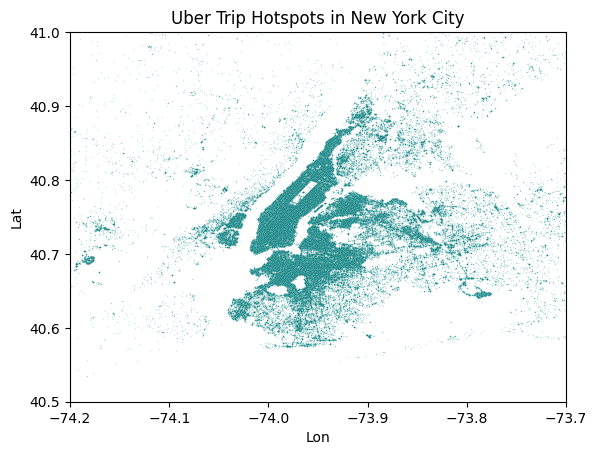

In [24]:
sns.scatterplot(
    data=df, x="Lon", y="Lat", s=1, alpha=0.2, color="teal"
).set(xlim=(-74.2, -73.7), ylim=(40.5, 41.0))
plt.title('Uber Trip Hotspots in New York City')

<Axes: xlabel='Hour', ylabel='Weekday'>

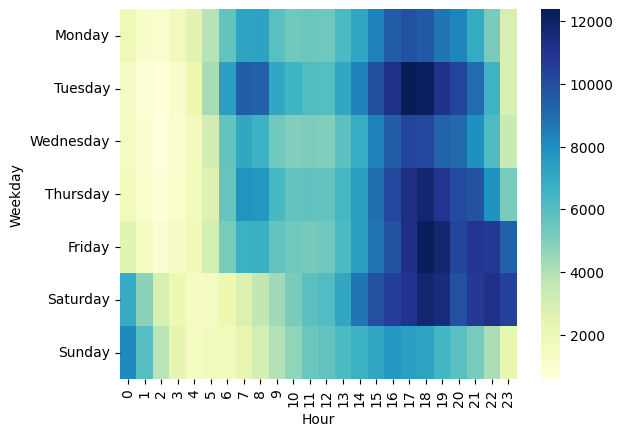

In [25]:
heat_data = pd.crosstab(df["Weekday"], df["Hour"])
sns.heatmap(
    heat_data.reindex(
        ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    ),
    cmap="YlGnBu",
)

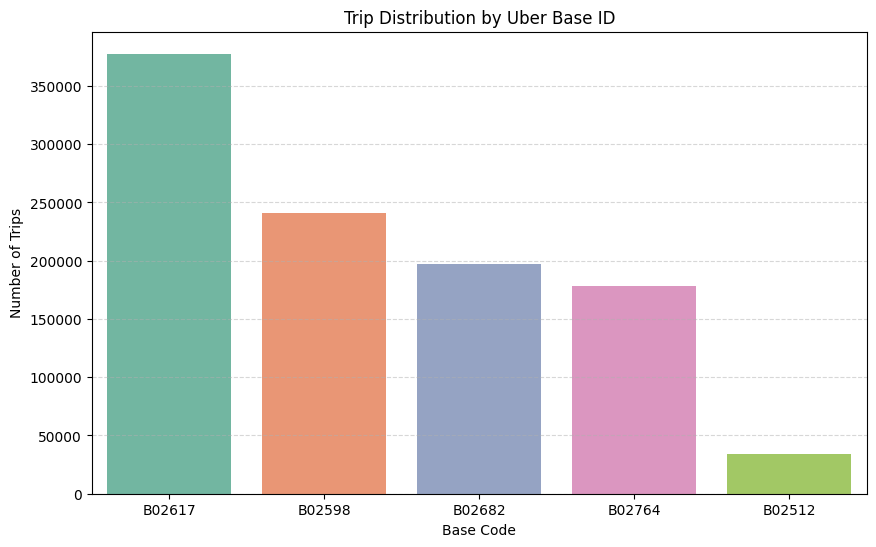

In [26]:
# Analyzing the frequency of each Base (Bar Chart)
plt.figure(figsize=(10, 6))
sns.countplot(x='Base', data=df, palette='Set2', order=df['Base'].value_counts().index)

plt.title('Trip Distribution by Uber Base ID')
plt.xlabel('Base Code')
plt.ylabel('Number of Trips')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

<Axes: ylabel='Lat,Lon'>

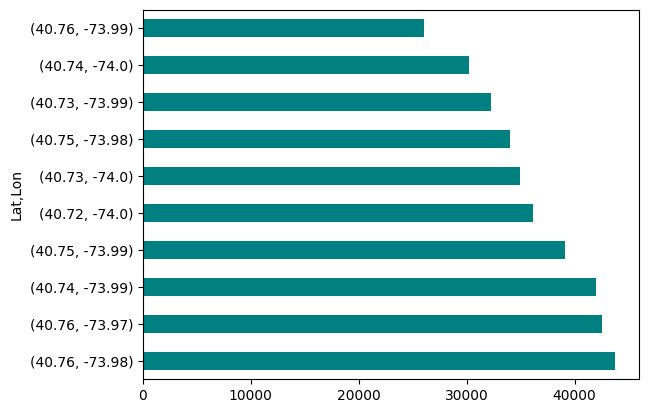

In [32]:
# Top 10 most frequent pickup coordinates (rounded to ~1km grid)
df.groupby([df["Lat"].round(2), df["Lon"].round(2)]).size().nlargest(10).plot.barh(color="teal")

<Axes: xlabel='Day'>

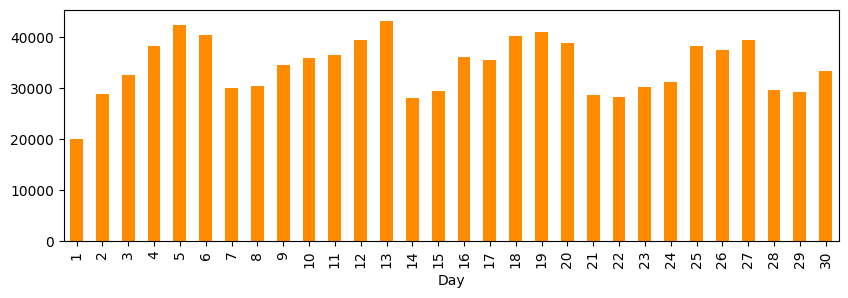

In [33]:
# Daily trip distribution across the days of the month
df["Day"].value_counts().sort_index().plot.bar(figsize=(10, 3), color="darkorange")

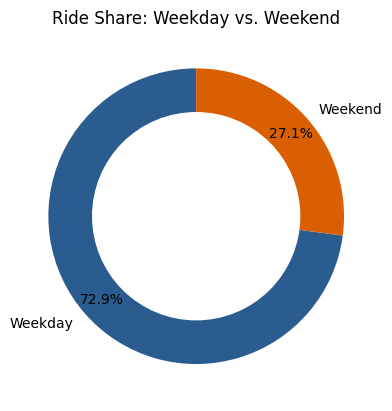

In [34]:
import matplotlib.pyplot as plt

# Donut Chart: Weekday vs Weekend share
is_weekend = df["Weekday"].isin(["Saturday", "Sunday"]).value_counts()

plt.pie(
    is_weekend,
    labels=["Weekday", "Weekend"],
    autopct="%1.1f%%",
    pctdistance=0.85,
    colors=["#2b5c8f", "#d95f02"],
    startangle=90,
)
plt.gca().add_artist(plt.Circle((0, 0), 0.70, color="white"))  # Hollow center
plt.title("Ride Share: Weekday vs. Weekend")
plt.show()

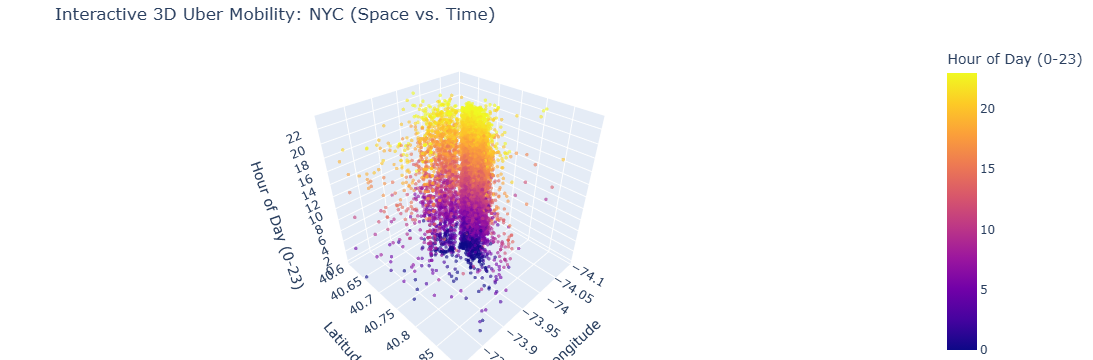

In [36]:
import plotly.express as px

# Subsample 10,000 points for smooth browser performance
sample_df = df.sample(n=min(10000, len(df)), random_state=42)

# Create an interactive 3D scatter plot using Plotly
fig = px.scatter_3d(
    sample_df,
    x="Lon",
    y="Lat",
    z="Hour",
    color="Hour",
    color_continuous_scale="Plasma",
    opacity=0.6,
    title="Interactive 3D Uber Mobility: NYC (Space vs. Time)",
    labels={
        "Lon": "Longitude",
        "Lat": "Latitude",
        "Hour": "Hour of Day (0-23)",
    },
)

# Customize marker size and set axis limits focused on NYC
fig.update_traces(marker=dict(size=2))
fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-74.1, -73.8]),
        yaxis=dict(range=[40.6, 40.9]),
        zaxis=dict(dtick=2),
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

# Open the interactive plot in your default web browser
fig.show()

This Exploratory Data Analysis (EDA) examined urban mobility dynamics using Uber trip record data in New York City. By analyzing spatial coordinates and timestamps across hourly, daily, and monthly dimensions, the study uncovered clear temporal patterns and geographic demand hotspots that govern ride-hailing activity.